<a href="https://colab.research.google.com/github/ga642381/ML2021-Spring/blob/main/HW01/HW01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 1: COVID-19 Cases Prediction (Regression)**

Objectives:
* Solve a regression problem with deep neural networks (DNN).
* Understand basic DNN training tips.
* Get familiar with PyTorch.

# **Download Data**

In [1]:
tr_path = 'covid.train.csv'  # path to training data
tt_path = 'covid.test.csv'   # path to testing data

#!gdown --id '19CCyCgJrUxtvgZF53vnctJiOJ23T5mqF' --output covid.train.csv
#!gdown --id '1CE240jLm2npU-tdz81-oVKEF3T2yfT1O' --output covid.test.csv

# **Import Some Packages**

In [2]:
# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# For data preprocess
import numpy as np
import csv
import os

# For plotting
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

import json

myseed = 42069  # set a random seed for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(myseed)
torch.manual_seed(myseed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(myseed)

# **Some Utilities**

You do not need to modify this part.

In [3]:
def get_device():
    ''' Get device (if GPU is available, use GPU) '''
    return 'cuda' if torch.cuda.is_available() else 'cpu'

def plot_learning_curve(loss_record, title=''):
    ''' Plot learning curve of your DNN (train & dev loss) '''
    # 获取训练的总步数
    total_steps = len(loss_record['train'])
    # 生成训练损失数据的横坐标
    x_1 = range(total_steps)
    # 根据训练和开发损失数据的比例生成开发损失数据的横坐标
    dev_steps = len(loss_record['dev'])
    x_2 = range(0, total_steps, total_steps // dev_steps)
    # 创建一个新的图形对象，设置图形的大小
    figure(figsize=(6, 4))
    # 绘制训练损失曲线，使用红色标记，标签为'train'
    plt.plot(x_1, loss_record['train'], c='tab:red', label='train')
    # 绘制开发损失曲线，使用青色标记，标签为'dev'
    plt.plot(x_2, loss_record['dev'], c='tab:cyan', label='dev')
    # 设置图形的y轴范围
    plt.ylim(0.0, 1.5)
    # 设置图形的x轴标签
    plt.xlabel('Training steps')
    # 设置图形的y轴标签
    plt.ylabel('loss')
    # 设置图形的标题，格式化标题为'Learning curve of '加上函数的title参数
    plt.title('Learning curve of {}'.format(title))
    # 添加图例以区分训练和开发损失曲线
    plt.legend()
    # 显示图形
    plt.show()
"""
def plot_learning_curve(loss_record, title=''):
    ''' Plot learning curve of your DNN (train & dev loss) '''
    # 固定训练的总步数为25000
    total_steps = 25000
    # 生成训练损失数据的横坐标
    x_1 = range(total_steps)
    # 根据训练和开发损失数据的比例生成开发损失数据的横坐标
    dev_steps = len(loss_record['dev'])
    x_2 = np.linspace(0, total_steps - 1, dev_steps, dtype=int)
    # 创建一个新的图形对象，设置图形的大小
    plt.figure(figsize=(6, 4))
    # 绘制训练损失曲线，使用红色标记，标签为'train'
    plt.plot(x_1[:len(loss_record['train'])], loss_record['train'], c='tab:red', label='train')
    # 绘制开发损失曲线，使用青色标记，标签为'dev'
    plt.plot(x_2[:len(loss_record['dev'])], loss_record['dev'], c='tab:cyan', label='dev')
    # 设置图形的y轴范围
    plt.ylim(0.0, 2.)
    # 设置图形的x轴标签
    plt.xlabel('Training steps')
    # 设置图形的y轴标签
    plt.ylabel('loss')
    # 设置图形的标题，格式化标题为'Learning curve of '加上函数的title参数
    plt.title('Learning curve of {}'.format(title))
    # 添加图例以区分训练和开发损失曲线
    plt.legend()
    # 显示图形
    plt.show()
"""
def plot_pred(dv_set, model, device, lim=35., preds=None, targets=None):
    ''' Plot prediction of your DNN '''
    if preds is None or targets is None:
        model.eval()
        preds, targets = [], []
        for x, y in dv_set:
            x, y = x.to(device), y.to(device)
            with torch.no_grad():
                pred = model(x)
                preds.append(pred.detach().cpu())
                targets.append(y.detach().cpu())
        preds = torch.cat(preds, dim=0).numpy()
        targets = torch.cat(targets, dim=0).numpy()

    figure(figsize=(5, 5))
    plt.scatter(targets, preds, c='r', alpha=0.5)
    plt.plot([-0.2, lim], [-0.2, lim], c='b')
    plt.xlim(-0.2, lim)
    plt.ylim(-0.2, lim)
    plt.xlabel('ground truth value')
    plt.ylabel('predicted value')
    plt.title('Ground Truth v.s. Prediction')
    plt.show()

# **Preprocess**

We have three kinds of datasets:
* `train`: for training
* `dev`: for validation
* `test`: for testing (w/o target value)

## **Dataset**

The `COVID19Dataset` below does:
* read `.csv` files
* extract features
* split `covid.train.csv` into train/dev sets
* normalize features

Finishing `TODO` below might make you pass medium baseline.

In [4]:
class COVID19Dataset(Dataset):
    ''' Dataset for loading and preprocessing the COVID19 dataset '''
    def __init__(self,
                 path,
                 mode='train',
                 target_only=False):
        self.mode = mode

        # Read data into numpy arrays
        with open(path, 'r') as fp:
            data = list(csv.reader(fp))
            data = np.array(data[1:])[:, 1:].astype(float)

        if not target_only:
            feats = list(range(93))
        else:
            # TODO: Using 40 states & 2 tested_positive features (indices = 57 & 75)
            pass

        if mode == 'test':
            # Testing data
            # data: 893 x 93 (40 states + day 1 (18) + day 2 (18) + day 3 (17))
            data = data[:, feats]
            self.data = torch.FloatTensor(data)
        else:
            # Training data (train/dev sets)
            # data: 2700 x 94 (40 states + day 1 (18) + day 2 (18) + day 3 (18))
            target = data[:, -1]
            data = data[:, feats]

            # Splitting training data into train & dev sets
            if mode == 'train':
                indices = [i for i in range(len(data)) if i % 10 != 0]
            elif mode == 'dev':
                indices = [i for i in range(len(data)) if i % 10 == 0]

            # Convert data into PyTorch tensors
            self.data = torch.FloatTensor(data[indices])
            self.target = torch.FloatTensor(target[indices])

        # Normalize features (you may remove this part to see what will happen)
        self.data[:, 40:] = \
            (self.data[:, 40:] - self.data[:, 40:].mean(dim=0, keepdim=True)) \
            / self.data[:, 40:].std(dim=0, keepdim=True)

        self.dim = self.data.shape[1]

        print('Finished reading the {} set of COVID19 Dataset ({} samples found, each dim = {})'
              .format(mode, len(self.data), self.dim))

    def __getitem__(self, index):
        # Returns one sample at a time
        if self.mode in ['train', 'dev']:
            # For training
            return self.data[index], self.target[index]
        else:
            # For testing (no target)
            return self.data[index]

    def __len__(self):
        # Returns the size of the dataset
        return len(self.data)

## **DataLoader**

A `DataLoader` loads data from a given `Dataset` into batches.


In [5]:
def prep_dataloader(path, mode, batch_size, n_jobs=0, target_only=False):
    ''' Generates a dataset, then is put into a dataloader. '''
    dataset = COVID19Dataset(path, mode=mode, target_only=target_only)  # Construct dataset
    dataloader = DataLoader(
        dataset, batch_size,
        shuffle=(mode == 'train'), drop_last=False,
        num_workers=n_jobs, pin_memory=True)                            # Construct dataloader
    return dataloader

# **Deep Neural Network**

`NeuralNet` is an `nn.Module` designed for regression.
The DNN consists of 2 fully-connected layers with ReLU activation.
This module also included a function `cal_loss` for calculating loss.


In [6]:
class NeuralNet(nn.Module):
    ''' A simple fully-connected deep neural network '''
    def __init__(self, input_dim):
        super(NeuralNet, self).__init__()

        # Define your neural network here
        # TODO: How to modify this model to achieve better performance?
        """self.net = nn.Sequential(
            nn.Linear(input_dim,64),   # 扩宽第一层神经元数量
            nn.ReLU(),
            
            nn.Linear(64, 16), 
            nn.ReLU(),

            #nn.Linear(32, 16),
            #nn.ReLU(),
            nn.Linear(16, 1)
        )"""
        self.net = nn.Sequential(
            nn.Linear(input_dim, 96),
            nn.ReLU(),
    
            nn.Linear(96, 16),
            nn.ReLU(),

            
            nn.Linear(16, 1)
        )
        # Mean squared error loss
        self.criterion = nn.MSELoss(reduction='mean')

    def forward(self, x):
        ''' Given input of size (batch_size x input_dim), compute output of the network '''
        return self.net(x).squeeze(1)

    def cal_loss(self, pred, target):
        ''' Calculate loss with L2 regularization '''
        loss = self.criterion(pred, target)
        l2_reg = 0
        for param in self.parameters():
            l2_reg += torch.norm(param, p=2)
        loss += 10.0 * 1e-4 * l2_reg  # 添加 L2 正则化项
        return loss

# **Train/Dev/Test**

## **Training**

In [7]:
def train(tr_set, dv_set, model, config, device):
    ''' DNN training '''

    n_epochs = config['n_epochs']  # Maximum number of epochs

    # Setup optimizer
    optimizer = getattr(torch.optim, config['optimizer'])(
        model.parameters(), **config['optim_hparas'])

    min_mse = 1000.
    loss_record = {'train': [], 'dev': []}      # for recording training loss
    early_stop_cnt = 0
    epoch = 0
    while epoch < n_epochs:
        model.train()                           # set model to training mode
        for x, y in tr_set:                     # iterate through the dataloader
            optimizer.zero_grad()               # set gradient to zero
            x, y = x.to(device), y.to(device)   # move data to device (cpu/cuda)
            pred = model(x)                     # forward pass (compute output)
            train_loss = model.cal_loss(pred, y)  # compute loss
            train_loss.backward()                 # compute gradient (backpropagation)
            optimizer.step()                    # update model with optimizer
            loss_record['train'].append(train_loss.detach().cpu().item())

        # After each epoch, test your model on the validation (development) set.
        dev_mse = dev(dv_set, model, device)
        if dev_mse < min_mse:
            # Save model if your model improved
            min_mse = dev_mse
            print('Saving model (epoch = {:4d}, dev_loss = {:.4f}),train_loss = {:.4f}'
                .format(epoch + 1, min_mse,train_loss))
            torch.save(model.state_dict(), config['save_path'])  # Save model to specified path
            early_stop_cnt = 0
        else:
            early_stop_cnt += 1

        epoch += 1
        loss_record['dev'].append(dev_mse)
        if early_stop_cnt > config['early_stop']:
            # Stop training if your model stops improving for "config['early_stop']" epochs.
            break

    print('Finished training after {} epochs'.format(epoch))
    loss_record_file = f"loss_record.json"
    with open(loss_record_file, 'w') as f:
        json.dump(loss_record, f)
    return min_mse, loss_record



## **Validation**

In [8]:
def dev(dv_set, model, device):
    model.eval()                                # set model to evalutation mode
    total_loss = 0
    for x, y in dv_set:                         # iterate through the dataloader
        x, y = x.to(device), y.to(device)       # move data to device (cpu/cuda)
        with torch.no_grad():                   # disable gradient calculation
            pred = model(x)                     # forward pass (compute output)
            mse_loss = model.cal_loss(pred, y)  # compute loss
        total_loss += mse_loss.detach().cpu().item() * len(x)  # accumulate loss
    total_loss = total_loss / len(dv_set.dataset)              # compute averaged loss

    return total_loss

## **Testing**

In [9]:
def test(tt_set, model, device):
    model.eval()                                # set model to evalutation mode
    preds = []
    for x in tt_set:                            # iterate through the dataloader
        x = x.to(device)                        # move data to device (cpu/cuda)
        with torch.no_grad():                   # disable gradient calculation
            pred = model(x)                     # forward pass (compute output)
            preds.append(pred.detach().cpu())   # collect prediction
    preds = torch.cat(preds, dim=0).numpy()     # concatenate all predictions and convert to a numpy array
    return preds

# **Setup Hyper-parameters**

`config` contains hyper-parameters for training and the path to save your model.

In [10]:
device = get_device()                 # get the current available device ('cpu' or 'cuda')
os.makedirs('models', exist_ok=True)  # The trained model will be saved to ./models/
target_only = False                   # TODO: Using 40 states & 2 tested_positive features

# TODO: How to tune these hyper-parameters to improve your model's performance?
config = {
    'n_epochs': 4000,
    'batch_size': 196,
    'optimizer': 'Adam',               # 换用 Adam 优化器
    'optim_hparas': {'lr': 0.00175},     # 学习率
    'early_stop': 100,                 # 提前停止的 patience 调低
    'save_path': 'models/model.pth'
}

# **Load data and model**

In [11]:
tr_set = prep_dataloader(tr_path, 'train', config['batch_size'], target_only=target_only)
dv_set = prep_dataloader(tr_path, 'dev', config['batch_size'], target_only=target_only)
tt_set = prep_dataloader(tt_path, 'test', config['batch_size'], target_only=target_only)

Finished reading the train set of COVID19 Dataset (2430 samples found, each dim = 93)
Finished reading the dev set of COVID19 Dataset (270 samples found, each dim = 93)
Finished reading the test set of COVID19 Dataset (893 samples found, each dim = 93)


In [12]:
model = NeuralNet(tr_set.dataset.dim).to(device)  # Construct model and move to device

# **Start Training!**

In [13]:
model_loss, model_loss_record = train(tr_set, dv_set, model, config, device)

Saving model (epoch =    1, dev_loss = 273.1368),train_loss = 267.2137
Saving model (epoch =    2, dev_loss = 156.4227),train_loss = 198.5520
Saving model (epoch =    3, dev_loss = 40.6281),train_loss = 44.6812
Saving model (epoch =    4, dev_loss = 35.8992),train_loss = 38.5613
Saving model (epoch =    5, dev_loss = 24.3102),train_loss = 21.9249
Saving model (epoch =    6, dev_loss = 21.2059),train_loss = 23.9906
Saving model (epoch =    7, dev_loss = 18.4992),train_loss = 15.0237
Saving model (epoch =    8, dev_loss = 16.0565),train_loss = 19.8844
Saving model (epoch =    9, dev_loss = 13.9424),train_loss = 17.8800
Saving model (epoch =   10, dev_loss = 12.0197),train_loss = 11.5768
Saving model (epoch =   11, dev_loss = 10.2755),train_loss = 8.2017
Saving model (epoch =   12, dev_loss = 8.7150),train_loss = 9.0992
Saving model (epoch =   13, dev_loss = 7.3650),train_loss = 8.4555
Saving model (epoch =   14, dev_loss = 6.0943),train_loss = 8.2123
Saving model (epoch =   15, dev_loss 

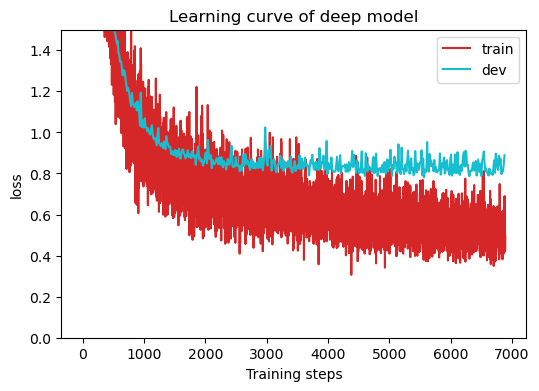

In [14]:
plot_learning_curve(model_loss_record, title='deep model')

/tmp/ipykernel_351423/1425700501.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(config['save_path'], map_location='cpu')  # Load your best model


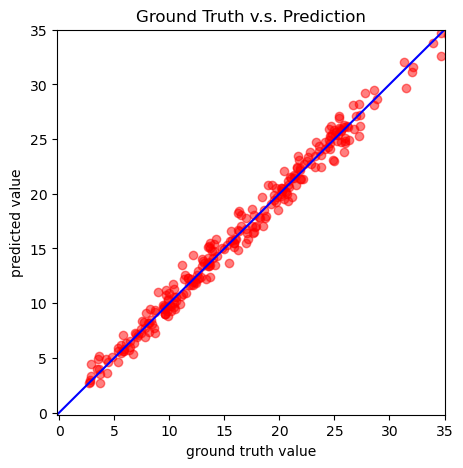

In [15]:
del model
model = NeuralNet(tr_set.dataset.dim).to(device)
ckpt = torch.load(config['save_path'], map_location='cpu')  # Load your best model
model.load_state_dict(ckpt)
plot_pred(dv_set, model, device)  # Show prediction on the validation set

TODO:

1. Observe the influence of hyperparameters on model performance, such as batch size and learning rate (at least these two types of hypterparameters, and choose 3 values for each one). If you plan to use more advanced component, please also report your hyperparameters. To observe training process with different hyperparameters, plot all your training loss and validation loss versus iteration (e.g., such as above figure showed by using *plot_learning_curve* mehtod) under different hyperparameters in one figure.

2. Save model that obtain the best performance on validation set and wirte the code to report average error. Note that, we use this error to create a leaderboard.

# **Testing**
Commonly，after selecting the best model by using validation set, the learned model can be deployed in real world application. The performance can be evluated by testing set. The predictions of your model on testing set will be stored at `pred.csv`.

In [16]:
def save_pred(preds, file):
    ''' Save predictions to specified file '''
    print('Saving results to {}'.format(file))
    with open(file, 'w') as fp:
        writer = csv.writer(fp)
        writer.writerow(['id', 'tested_positive'])
        for i, p in enumerate(preds):
            writer.writerow([i, p])

preds = test(tt_set, model, device)  # predict COVID-19 cases with your model
save_pred(preds, 'pred.csv')         # save prediction file to pred.csv

Saving results to pred.csv


Compasrion of different settings

In [17]:
# 加载 loss_record 文件
def load_loss_record(file_path):
    with open(file_path, 'r') as f:
        loss_record = json.load(f)
    return loss_record

# 绘制学习曲线
def plot_all_curves(loss_records, titles, total_steps=25000):
    ''' Plot learning curves of multiple DNNs (train & dev loss) '''
    plt.figure(figsize=(12, 8))
    
    for i, (loss_record, title) in enumerate(zip(loss_records, titles)):
        # 生成训练损失数据的横坐标
        x_1 = range(min(total_steps, len(loss_record['train'])))
        # 生成开发损失数据的横坐标
        dev_steps = len(loss_record['dev'])
        x_2 = np.linspace(0, min(total_steps - 1, len(loss_record['train']) - 1), dev_steps, dtype=int)
        
        # 绘制训练损失曲线
        #plt.plot(x_1, loss_record['train'][:total_steps], label=f'{title} train', linestyle='--', linewidth=1.5)
        # 绘制开发损失曲线
        plt.plot(x_2, loss_record['dev'][:total_steps], label=f'{title} dev', linestyle='-', linewidth=1.5)
    
    # 设置图形的y轴范围
    plt.ylim(0.6, 1.0)
    # 设置图形的x轴标签
    plt.xlabel('Training steps')
    # 设置图形的y轴标签
    plt.ylabel('Loss')
    # 设置图形的标题
    plt.title('Learning Curves of Different Models')
    # 添加图例以区分训练和开发损失曲线
    plt.legend()
    # 显示图形
    plt.grid(True)
    plt.show()

# 文件路径
file_paths = [
    '/home/m/桌面/My project/4981/hw1/loss_record_batch300.json',
    '/home/m/桌面/My project/4981/hw1/loss_record_L2_1e-3_2layers64-32.json',
    '/home/m/桌面/My project/4981/hw1/loss_record_layer48-16.json',
    '/home/m/桌面/My project/4981/hw1/loss_record_layer64-16.json',
    '/home/m/桌面/My project/4981/hw1/loss_record_layer96-16.json',
    '/home/m/桌面/My project/4981/hw1/loss_record_lr0001.json',
    '/home/m/桌面/My project/4981/hw1/loss_record_lr00015.json',
    '/home/m/桌面/My project/4981/hw1/loss_record_ls00015.json',
    'loss_record073.json',
    'loss_record.json'
]

# 标题
titles = [
    'batch300',
    'L2_1e-3_2layers64-32',
    'layer48-16',
    'layer64-16',
    'layer96-16',
    'lr0001',
    'lr00015',
    'ls00015',
    'loss_record073',
    'loss_record'
]

# 加载 loss_record
loss_records = [load_loss_record(file_path) for file_path in file_paths]

# 绘制学习曲线
plot_all_curves(loss_records, titles)

FileNotFoundError: [Errno 2] No such file or directory: '/home/m/桌面/My project/4981/hw1/loss_record_batch300.json'

# **Hints**

## **Simple Baseline**
* Run sample code

## **Medium Baseline**
* Feature selection: 40 states + 2 `tested_positive` (`TODO` in dataset)

## **Strong Baseline**
* Feature selection (what other features are useful?)
* DNN architecture (layers? dimension? activation function?)
* Training (mini-batch? optimizer? learning rate?)
* L2 regularization
* There are some mistakes in the sample code, can you find them?

## **TODO:**

---
1. Observe the influence of hyperparameters on model performance, such as batch size and learning rate (at least these two types of hypterparameters, and choose 3 values for each one). If you plan to use more advanced component, please also report your hyperparameters. To observe training process with different hyperparameters, **plot all your training loss and validation loss versus iteration (e.g., such as above figure showed by using *plot_learning_curve()* mehtod) under different hyperparameters in one figure.**

---

2. Save the best model that obtains the lowest error on validation set. Wirte the code to let the best model to show the lowest error. Note that, we will use this error to create a leaderboard. **Your ranking will be used as an important prerequisite to determine your score.**

---
